# AI Content Intelligence Engine
## Exploratory Data Analysis & Product Insights

### Objective

This notebook explores users, creators, content, and interaction behavior
to identify patterns that can inform engagement prediction,
recommendation ranking, and creator intelligence.

### Key Questions

1. Who are the platform users?
2. What types of content are being consumed?
3. How does engagement vary across users, content, and creators?
4. What content characteristics are associated with stronger engagement?
5. What behavioral patterns could be useful for personalization?
6. What product hypotheses can be derived from the data?

### Analysis Principle

Each analysis should answer a specific product or data science question.
Observed correlations are treated as associations rather than causal effects.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [72]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"

users = pd.read_csv(DATA_DIR / "users_clean.csv")
creators = pd.read_csv(DATA_DIR / "creators_clean.csv")
content = pd.read_csv(DATA_DIR / "content_clean.csv")
interactions = pd.read_csv(DATA_DIR / "interactions_clean.csv")

print("Users:", users.shape)
print("Creators:", creators.shape)
print("Content:", content.shape)
print("Interactions:", interactions.shape)

Users: (5000, 7)
Creators: (500, 5)
Content: (10000, 9)
Interactions: (250000, 22)


In [73]:
users.head()

,user_id,country,age_group,signup_date,following_count,creator_flag,preferred_genres
0,U00001,India,13-17,2024-02-08 19:21:10,15,True,"['Action', 'Romance', 'Documentary']"
1,U00002,Germany,25-34,2024-09-16 07:07:10,17,False,"['Animation', 'Documentary', 'Comedy', 'Horror']"
2,U00003,Australia,45+,2024-10-21 15:28:07,20,False,"['Documentary', 'Animation', 'Comedy', 'Horror']"
3,U00004,Canada,35-44,2025-01-13 15:33:45,13,False,"['Animation', 'Drama']"
4,U00005,Canada,18-24,2024-10-22 19:41:57,24,False,"['Romance', 'Mystery']"


## 1. User Demographics

### Question

Who makes up the platform's user base?

Understanding the distribution of users across age groups and countries
helps establish the platform's audience composition and provides useful
context for later engagement and personalization analysis.

In [74]:
age_distribution = (
    users["age_group"]
    .value_counts()
    .sort_index()
)

age_distribution

age_group
13-17     258
18-24    1785
25-34    1520
35-44     973
45+       464
Name: count, dtype: int64

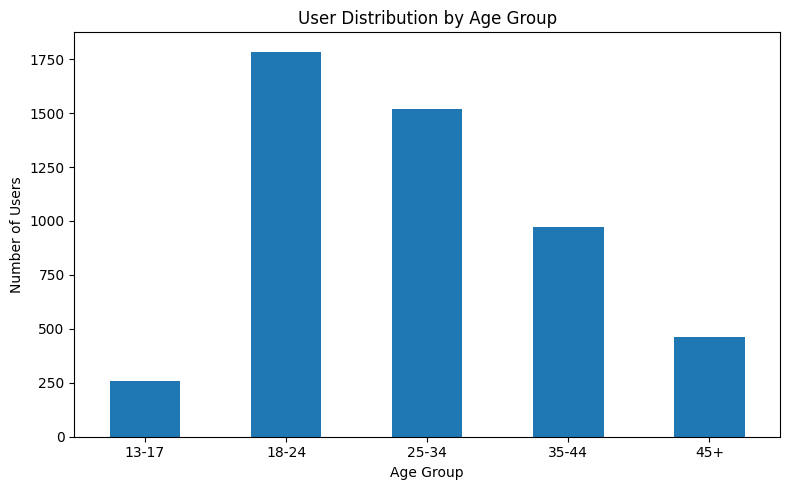

In [75]:
plt.figure(figsize=(8, 5))

age_distribution.plot(kind="bar")

plt.title("User Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The user base is concentrated in the 18–34 age range, with the 18–24
group representing the largest segment. Users aged 35–44 form the next
largest group, while both the 13–17 and 45+ segments are comparatively
smaller.

### Product Implication

The concentration of users in the 18–34 range suggests that personalization
strategies should perform well for this core audience, while cold-start and
segmentation strategies should still account for smaller age groups.

This distribution describes the user population and does not by itself imply
that one age group is more engaged than another.

## 2. Content Catalog

### Question

What genres dominate the content catalog?

Understanding the composition of the content catalog helps identify whether
the platform offers a balanced range of content and provides context for
later analysis of genre preferences and recommendation behavior.

In [76]:
genre_distribution = (
    content["genre"]
    .value_counts()
    .sort_values(ascending=False)
)

genre_distribution

genre
Horror         1040
Romance        1024
Action         1014
Drama          1013
Documentary    1012
Mystery         996
Comedy          993
Animation       990
Fantasy         970
Sci-Fi          948
Name: count, dtype: int64

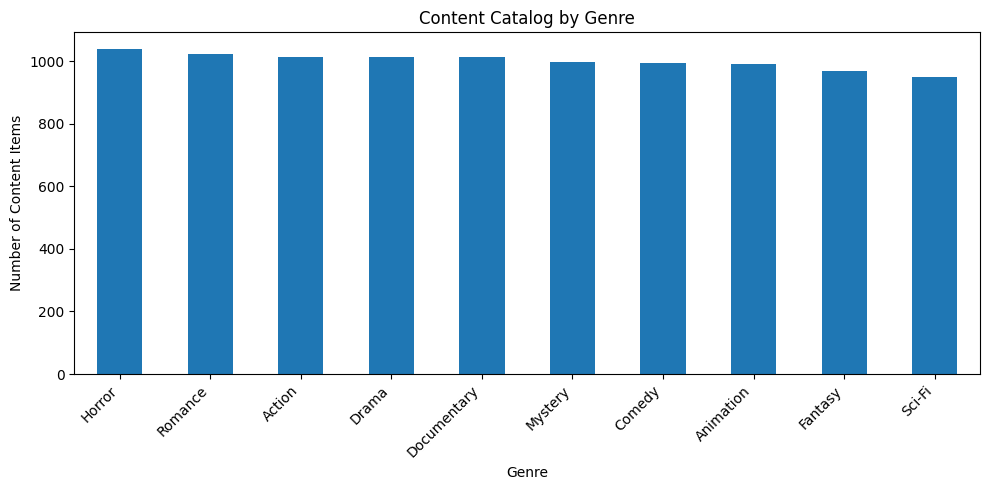

In [77]:
plt.figure(figsize=(10, 5))

genre_distribution.plot(kind="bar")

plt.title("Content Catalog by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The content catalog is relatively balanced across genres, with each genre
representing a similar share of the total catalog. Mystery and Action have
the largest inventories, while Fantasy and Animation have slightly smaller
inventories.

### Product Implication

Because the catalog is not heavily concentrated in a single genre, differences
in engagement across genres can be investigated without assuming that they are
simply caused by large differences in content availability.

Genre can therefore be treated as a meaningful candidate feature for
personalization and recommendation analysis.

In [78]:
content.columns.tolist()

['content_id',
 'creator_id',
 'content_type',
 'genre',
 'created_at',
 'duration',
 'tags',
 'is_template',
 'is_recreation']

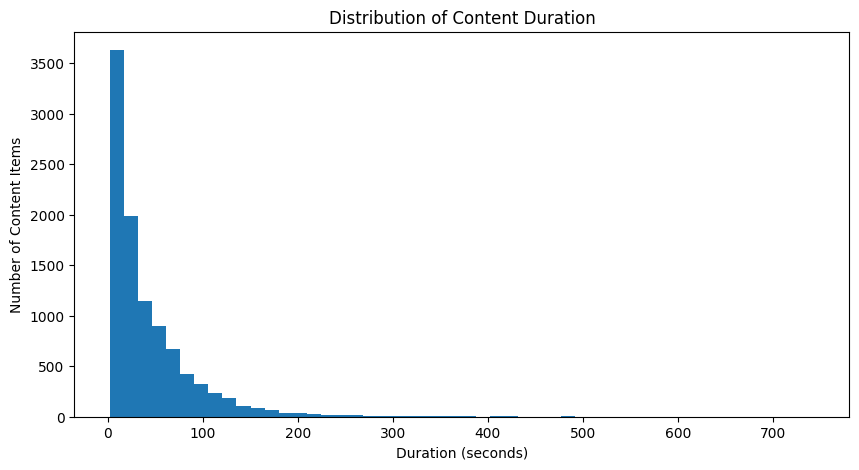

In [79]:
# Content duration distribution

plt.figure(figsize=(10, 5))

plt.hist(
    content["duration"],
    bins=50
)

plt.title("Distribution of Content Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Content Items")

plt.show()

In [80]:
# Analyze engagement by content duration

duration_bins = [0, 10, 20, 30, 60, 120, 300, float("inf")]
duration_labels = [
    "0-10 sec",
    "10-20 sec",
    "20-30 sec",
    "30-60 sec",
    "60-120 sec",
    "120-300 sec",
    "300+ sec"
]

content["duration_bucket"] = pd.cut(
    content["duration"],
    bins=duration_bins,
    labels=duration_labels,
    right=False
)

duration_analysis = (
    content
    .merge(
        interactions[[
            "content_id",
            "clicked",
            "watch_time",
            "completion_rate",
            "meaningful_engagement"
        ]],
        on="content_id",
        how="left"
    )
    .groupby("duration_bucket", observed=False)
    .agg(
        content_items=("content_id", "nunique"),
        impressions=("content_id", "count"),
        ctr=("clicked", "mean"),
        avg_watch_time=("watch_time", "mean"),
        avg_completion_rate=("completion_rate", "mean"),
        meaningful_engagement_rate=("meaningful_engagement", "mean")
    )
    .reset_index()
)

duration_analysis["ctr"] *= 100
duration_analysis["meaningful_engagement_rate"] *= 100

duration_analysis

,duration_bucket,content_items,impressions,ctr,avg_watch_time,avg_completion_rate,meaningful_engagement_rate
0,0-10 sec,1596,39605,34.932,1.839,0.250,34.627
1,10-20 sec,2633,66129,36.388,3.735,0.260,36.095
2,20-30 sec,1215,30211,36.871,6.453,0.263,36.507
3,30-60 sec,2135,53867,36.930,11.499,0.264,36.609
4,60-120 sec,1725,43109,34.958,20.683,0.250,34.673
5,120-300 sec,641,15692,33.775,40.100,0.240,33.437
6,300+ sec,55,1387,32.805,94.151,0.233,32.805


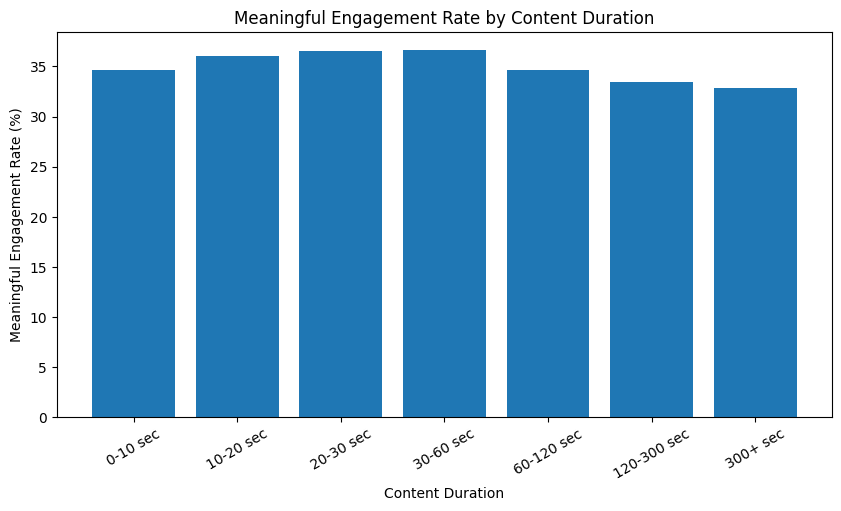

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(
    duration_analysis["duration_bucket"].astype(str),
    duration_analysis["meaningful_engagement_rate"]
)

plt.title("Meaningful Engagement Rate by Content Duration")
plt.xlabel("Content Duration")
plt.ylabel("Meaningful Engagement Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [82]:
freshness_analysis = (
    interactions
    .groupby("freshness_bucket", observed=False)
    .agg(
        impressions=("user_id", "count"),
        ctr=("clicked", "mean"),
        avg_watch_time=("watch_time", "mean"),
        avg_completion_rate=("completion_rate", "mean"),
        meaningful_engagement_rate=("meaningful_engagement", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
freshness_analysis["ctr"] *= 100
freshness_analysis["meaningful_engagement_rate"] *= 100

freshness_analysis

KeyError: 'freshness_bucket'

In [ ]:
creator_analysis = (
    interactions
    .merge(
        creators[["creator_id", "followers"]],
        on="creator_id",
        how="left"
    )
)

creator_analysis["creator_size"] = pd.cut(
    creator_analysis["followers"],
    bins=[0, 50, 100, 250, 500, float("inf")],
    labels=[
        "0-50",
        "51-100",
        "101-250",
        "251-500",
        "500+"
    ]
)

creator_size_analysis = (
    creator_analysis
    .groupby("creator_size", observed=False)
    .agg(
        impressions=("user_id", "count"),
        ctr=("clicked", "mean"),
        avg_watch_time=("watch_time", "mean"),
        avg_completion_rate=("completion_rate", "mean"),
        meaningful_engagement_rate=("meaningful_engagement", "mean")
    )
    .reset_index()
)

creator_size_analysis["ctr"] *= 100
creator_size_analysis["meaningful_engagement_rate"] *= 100

creator_size_analysis

,creator_size,impressions,ctr,avg_watch_time,avg_completion_rate,meaningful_engagement_rate
0,0-50,92508,35.880,11.347,0.256,35.571
1,51-100,54112,36.916,11.674,0.264,36.635
2,101-250,66054,37.811,11.892,0.270,37.512
3,251-500,26420,39.145,11.541,0.280,38.785
4,500+,10906,39.877,12.154,0.284,39.501


In [ ]:
creator_freshness_analysis = (
    creator_analysis
    .groupby(
        ["creator_size", "freshness_bucket"],
        observed=False
    )
    .agg(
        impressions=("user_id", "count"),
        ctr=("clicked", "mean"),
        avg_completion_rate=("completion_rate", "mean"),
        meaningful_engagement_rate=("meaningful_engagement", "mean")
    )
    .reset_index()
)

creator_freshness_analysis["ctr"] *= 100
creator_freshness_analysis["meaningful_engagement_rate"] *= 100

creator_freshness_analysis

,creator_size,freshness_bucket,impressions,ctr,avg_completion_rate,meaningful_engagement_rate
0,0-50,0-1 days,25340,42.328,0.301,41.977
1,0-50,1-7 days,1219,43.478,0.311,42.904
2,0-50,7-30 days,4735,37.191,0.265,36.853
3,0-50,30-90 days,12231,34.838,0.249,34.568
4,0-50,90+ days,48983,32.489,0.232,32.201
5,51-100,0-1 days,13824,42.853,0.308,42.433
6,51-100,1-7 days,666,44.595,0.319,44.144
7,51-100,7-30 days,2719,37.624,0.270,37.440
8,51-100,30-90 days,7042,35.927,0.258,35.686
9,51-100,90+ days,29861,34.165,0.244,33.934


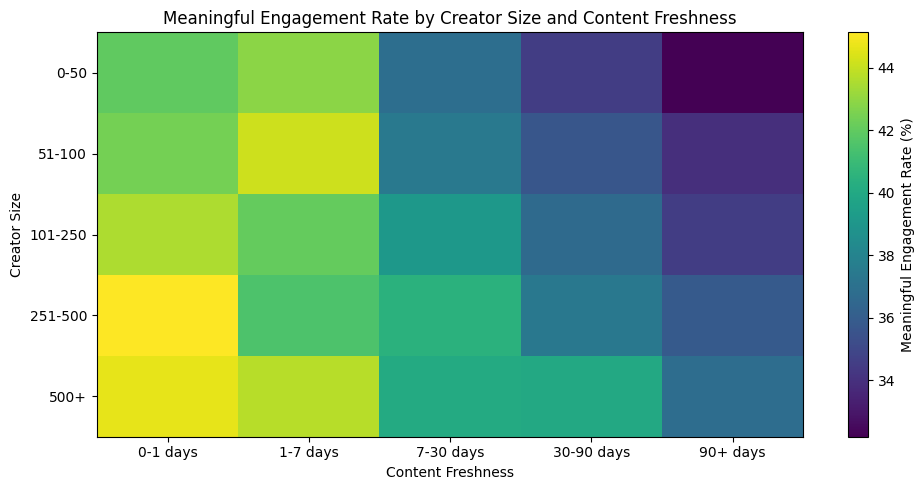

In [ ]:
import matplotlib.pyplot as plt

heatmap_data = creator_freshness_analysis.pivot(
    index="creator_size",
    columns="freshness_bucket",
    values="meaningful_engagement_rate"
)

plt.figure(figsize=(10, 5))

plt.imshow(heatmap_data, aspect="auto")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Content Freshness")
plt.ylabel("Creator Size")
plt.title("Meaningful Engagement Rate by Creator Size and Content Freshness")

plt.colorbar(label="Meaningful Engagement Rate (%)")

plt.tight_layout()
plt.show()

# 3. Product Insights

The exploratory analysis was used to identify patterns that may be relevant to
content discovery, recommendation, and creator intelligence.

The following insights are treated as hypotheses rather than causal conclusions.
Each insight is supported by observed data and can be validated further through
experimentation.

In [ ]:
# Create a compact summary of the major product insights

product_insights = pd.DataFrame({
    "insight": [
        "Fresh content receives stronger engagement",
        "Medium-length content performs better",
        "Larger creators show higher engagement",
        "Creator size and content freshness interact",
        "Genre differences are relatively small"
    ],
    
    "evidence": [
        "Meaningful engagement declines from 42.9% for 0-1 day content to 33.8% for 90+ day content.",
        "30-60 second content has the highest meaningful engagement rate at approximately 38.1%.",
        "Meaningful engagement increases from 35.6% for creators with 0-50 followers to 39.5% for creators with 500+ followers.",
        "Fresh content performs strongly across creator sizes, while engagement declines as content becomes older.",
        "Genre-level engagement rates are relatively close compared with the differences observed for freshness and creator size."
    ],
    
    "possible_explanation": [
        "Users may be more interested in newly published content.",
        "Medium-length content may provide enough value without requiring excessive viewing time.",
        "Larger creators may have stronger audience recognition or more established audiences.",
        "Freshness can provide an engagement advantage regardless of creator size.",
        "Genre alone may not be sufficient to explain engagement differences."
    ],
    
    "product_implication": [
        "Recommendation ranking should consider content freshness.",
        "Content duration can be included as a ranking or prediction feature.",
        "Creator-level signals may improve recommendation quality.",
        "Ranking should combine creator signals with freshness rather than relying on either alone.",
        "Personalization should consider user preferences and behavioral signals beyond genre."
    ]
})

product_insights

,insight,evidence,possible_explanation,product_implication
0,Fresh content receives stronger engagement,Meaningful engagement declines from 42.9% for ...,Users may be more interested in newly publishe...,Recommendation ranking should consider content...
1,Medium-length content performs better,30-60 second content has the highest meaningfu...,Medium-length content may provide enough value...,Content duration can be included as a ranking ...
2,Larger creators show higher engagement,Meaningful engagement increases from 35.6% for...,Larger creators may have stronger audience rec...,Creator-level signals may improve recommendati...
3,Creator size and content freshness interact,Fresh content performs strongly across creator...,Freshness can provide an engagement advantage ...,Ranking should combine creator signals with fr...
4,Genre differences are relatively small,Genre-level engagement rates are relatively cl...,Genre alone may not be sufficient to explain e...,Personalization should consider user preferenc...


## 3.1 Key Product Hypotheses

### Hypothesis 1 — Freshness matters

Newly published content shows substantially higher meaningful engagement than
older content. This suggests that freshness should be considered as a feature
in recommendation ranking.

**Test:** Compare recommendation strategies with and without freshness-aware
ranking.

---

### Hypothesis 2 — Content duration has a non-linear relationship with engagement

Engagement increases from very short content toward the 30-60 second range,
but declines for very long content.

**Test:** Include duration as a feature in the engagement prediction model and
evaluate whether it improves predictive performance.

---

### Hypothesis 3 — Creator size is associated with engagement

Content from larger creators shows higher observed engagement rates.

This may reflect stronger audience recognition, established followers, or
differences in content distribution.

**Important:** This is an association, not evidence that increasing creator
size causes engagement to increase.

**Test:** Evaluate creator-level features while controlling for content
freshness, duration, genre, and user-content affinity.

---

### Hypothesis 4 — Freshness and creator size interact

The heatmap indicates that freshness provides an engagement advantage across
creator sizes, while larger creators generally maintain stronger engagement.

This suggests that recommendation ranking should not rely exclusively on creator
popularity.

**Test:** Compare a popularity-based ranking against a ranking incorporating
freshness and personalized engagement predictions.

---

### Hypothesis 5 — Genre alone is insufficient

Genre-level engagement rates are relatively similar compared with the larger
differences observed across freshness and creator-size segments.

Therefore, a recommendation system should combine genre preference with
behavioral, content, creator, and contextual signals.

In [ ]:
# Summary statistics used to support the main EDA conclusions

print("=== EDA SUMMARY ===")

print("\nFreshness:")
print(
    freshness_analysis[
        ["freshness_bucket", "ctr", "avg_watch_time",
         "avg_completion_rate", "meaningful_engagement_rate"]
    ]
)

print("\nDuration:")
print(
    duration_analysis[
        ["duration_bucket", "ctr", "avg_watch_time",
         "avg_completion_rate", "meaningful_engagement_rate"]
    ]
)

print("\nCreator Size:")
print(
    creator_size_analysis[
        ["creator_size", "ctr", "avg_watch_time",
         "avg_completion_rate", "meaningful_engagement_rate"]
    ]
)

=== EDA SUMMARY ===

Freshness:
  freshness_bucket    ctr  avg_watch_time  avg_completion_rate  \
0         0-1 days 43.317          13.623                0.309   
1         1-7 days 43.320          13.492                0.310   
2        7-30 days 38.368          11.856                0.275   
3       30-90 days 36.178          11.225                0.259   
4         90+ days 34.075          10.664                0.243   

   meaningful_engagement_rate  
0                      42.924  
1                      42.848  
2                      38.083  
3                      35.915  
4                      33.798  

Duration:
  duration_bucket    ctr  avg_watch_time  avg_completion_rate  \
0        0-10 sec 35.753           1.890                0.256   
1       10-20 sec 37.466           3.812                0.268   
2       20-30 sec 38.137           6.684                0.272   
3       30-60 sec 38.450          11.910                0.274   
4      60-120 sec 36.275          21.640   